# PROYEK AKHIR UAS KALKULUS INTEGRAL BERBASIS PEMROGRAMAN
## Topik: Pemodelan Laju Produksi Multi-Fase (Misi 3)
**Nama Kelompok: Kelompok MBG**   
**Anggota Kelompok & NIM:**
1. [Irham Kadarusman] - [25051130056] (Koordinator Proyek)
2. [Klarizto Armanero Wibowo] - [25051130068] (Modeling Lead)
3. [Hanu Hermawan] - [25051130083] (Symbolic Lead)
4. [Labib Nur Hidayat] - [25051130044] (Numeric Lead)
5. [Roihan Anwar] - [25051130047] (Validation Lead)
6. [Rafif Athallah Pratama] - [25051130051] (Visualization Lead)

---
*Penanggung Jawab Cell Ini: Irham Kadarusman*

## Bagian A: Deskripsi Masalah dan Satuan
**Penanggung Jawab: Klarizto Armanero Wibowo**

### Konteks Skenario:
Skenario ini memodelkan laju produksi $P(t)$ suatu pabrik selama 1 shift kerja (8 jam).
- **Variabel Independen ($t$):** Waktu setelah shift dimulai (satuan: **jam**).
- **Variabel Dependen ($P(t)$):** Laju produksi komoditas (satuan: **unit/jam**).
- **Tujuan Integrasi:** Menghitung akumulasi total volume barang yang diproduksi ($Q$) dalam satuan **unit**.

## Bagian B: Model Matematis (Fungsi Piecewise)
### Persamaan Laju Produksi $P(t)$:
Fungsi dibagi menjadi 3 fase utama:
1. **Fase 1 (Akselerasi/Ramping Up):** $0 \le t \le 2$ -> $P_1(t) = 50t$
2. **Fase 2 (Konstan/Optimal):** $2 < t \le 6$ -> $P_2(t) = 100$
3. **Fase 3 (Deselerasi/Cooling Down):** $6 < t \le 8$ -> $P_3(t) = 100 - 50(t - 6)$

### Bentuk Integral Tentu Total:
$$Q = \int_{0}^{8} P(t) \,dt = \int_{0}^{2} 50t \,dt + \int_{2}^{6} 100 \,dt + \int_{6}^{8} (100 - 50(t - 6)) \,dt$$

### Bagian C: Solusi simbolik (SymPy) dan penyederhanaan hasil.

In [15]:
# ==============================================================================
# BAGIAN C: SOLUSI SIMBOLIK (ANALITIK) MENGGUNAKAN SYMPY
# Penanggung Jawab: Hanu Hermawan (SymPy)
# ==============================================================================

import sympy as sp

# 1. Definisi Simbol dan Parameter Kontrol
t = sp.Symbol('t', real=True)
t1, t2, t3 = 2, 6, 8 # Batas waktu antar fase (dapat diubah)

# 2. Definisi Fungsi per Fase secara Simbolik
P1 = 50 * t
P2 = 100
P3 = 100 - 50 * (t - 6)

# 3. Perhitungan Integral Analitik per Fase
Q1_sym = sp.integrate(P1, (t, 0, t1))
Q2_sym = sp.integrate(P2, (t, t1, t2))
Q3_sym = sp.integrate(P3, (t, t2, t3))

# 4. Akumulasi Total
Q_total_sym = Q1_sym + Q2_sym + Q3_sym

print("--- HASIL SOLUSI SIMBOLIK (EXAK) ---")
print(f"Hasil Eksak Fase 1: {Q1_sym} unit")
print(f"Hasil Eksak Fase 2: {Q2_sym} unit")
print(f"Hasil Eksak Fase 3: {Q3_sym} unit")
print(f"Total Produksi (Simbolik): {Q_total_sym} unit")

--- HASIL SOLUSI SIMBOLIK (EXAK) ---
Hasil Eksak Fase 1: 100 unit
Hasil Eksak Fase 2: 400 unit
Hasil Eksak Fase 3: 100 unit
Total Produksi (Simbolik): 600 unit


### Bagian D: Solusi numerik (NumPy) dengan minimal 2 resolusi sampling (misal n=1.000 dan n=100.000).

In [16]:
# ==============================================================================
# BAGIAN D: SOLUSI NUMERIK MENGGUNAKAN NUMPY
# Penanggung Jawab: Labib Nur Hidayat
# ==============================================================================

import numpy as np

# 1. Definisi Fungsi Piecewise Versi Numerik
def P_num(t_array):
    # Menggunakan np.piecewise untuk menangani fungsi multi-fase pada array
    condlist = [t_array <= 2, (t_array > 2) & (t_array <= 6), t_array > 6]
    funclist = [lambda t: 50*t, lambda t: 100, lambda t: 100 - 50*(t-6)]
    return np.piecewise(t_array, condlist, funclist)

# 2. Perhitungan dengan 2 Resolusi Sampling Sesuai Panduan (n=1.000 dan n=100.000)
resolusi = [1000, 100000]
hasil_numerik = {}

print("--- HASIL SOLUSI NUMERIK ---")
for n in resolusi:
    t_space = np.linspace(0, 8, n + 1)
    P_space = P_num(t_space)

    # Menghitung dengan metode Trapesium (np.trapz / np.integrate.trapezoid)
    Q_num_total = np.trapezoid(P_space, t_space)
    hasil_numerik[n] = Q_num_total
    print(f"Total Produksi dengan n = {n}: {Q_num_total:.6f} unit")

--- HASIL SOLUSI NUMERIK ---
Total Produksi dengan n = 1000: 600.000000 unit
Total Produksi dengan n = 100000: 600.000000 unit


### Bagian E: Validasi hasil (selisih absolut dan relatif, serta alasan perbedaan).

In [17]:
# ==============================================================================
# BAGIAN E: VALIDASI HASIL (ERROR ANALYSIS)
# Penanggung Jawab: Roihan Anwar
# ==============================================================================

print("--- EVALUASI DAN VALIDASI ERROR ---")
nilai_eksak = float(Q_total_sym)

for n in resolusi:
    nilai_numerik = hasil_numerik[n]

    # Perhitungan Absolute Error dan Relative Error
    abs_error = abs(nilai_eksak - nilai_numerik)
    rel_error = (abs_error / nilai_eksak) * 100 # dalam persen

    print(f"Resolusi n = {n}:")
    print(f"  - Absolute Error : {abs_error:.8f}")
    print(f"  - Relative Error : {rel_error:.8f} %")

--- EVALUASI DAN VALIDASI ERROR ---
Resolusi n = 1000:
  - Absolute Error : 0.00000000
  - Relative Error : 0.00000000 %
Resolusi n = 100000:
  - Absolute Error : 0.00000000
  - Relative Error : 0.00000000 %


### Bagian F: Visualisasi kurva dan area (untuk piecewise, tampilkan per fase).

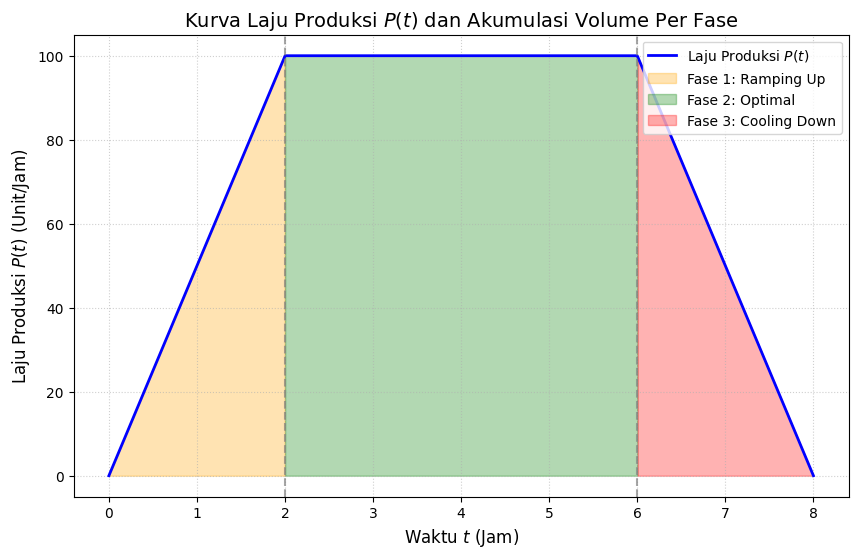

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# BAGIAN F: VISUALISASI KURVA DAN AREA (MATPLOTLIB)
# Penanggung Jawab: Rafif Athallah Pratama
# ==============================================================================


# 1. Sampling data untuk plotting halus
t_plot = np.linspace(0, 8, 2000)
P_plot = P_num(t_plot)

plt.figure(figsize=(10, 6))

# 2. Plot Garis Kurva Utama
plt.plot(t_plot, P_plot, label='Laju Produksi $P(t)$', color='blue', linewidth=2)

# 3. Pengarsiran Area Per Fase (Piecewise Shading)
plt.fill_between(t_plot, P_plot, where=(t_plot <= 2), alpha=0.3, color='orange', label='Fase 1: Ramping Up')
plt.fill_between(t_plot, P_plot, where=((t_plot > 2) & (t_plot <= 6)), alpha=0.3, color='green', label='Fase 2: Optimal')
plt.fill_between(t_plot, P_plot, where=(t_plot > 6), alpha=0.3, color='red', label='Fase 3: Cooling Down')

# 4. Anotasi Garis Pembatas Fase
plt.axvline(x=2, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=6, color='gray', linestyle='--', alpha=0.7)

# 5. Atribut Grafik
plt.title('Kurva Laju Produksi $P(t)$ dan Akumulasi Volume Per Fase', fontsize=14)
plt.xlabel('Waktu $t$ (Jam)', fontsize=12)
plt.ylabel('Laju Produksi $P(t)$ (Unit/Jam)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Menampilkan grafik
plt.show()

### Bagian G: Interpretasi hasil dan kesimpulan singkat.

## Bagian G: Interpretasi Hasil dan Kesimpulan
**Penanggung Jawab: Rafif Athallah Pratama**

### 1. Interpretasi Hasil Kontekstual
Berdasarkan hasil perhitungan komputasi, akumulasi volume total komoditas yang berhasil diproduksi oleh pabrik selama 1 shift kerja (8 jam) adalah **600 unit**.

Jika ditinjau secara dinamis per fase, kontribusi tiap segmen waktu terhadap total output adalah sebagai berikut:
* **Fase 1 (Jam 0 - 2):** Merupakan fase pemanasan (*ramping up*). Laju produksi meningkat secara linear, berkontribusi sebesar **100 unit** terhadap total produksi.
* **Fase 2 (Jam 2 - 6):** Merupakan fase operasi optimal (*steady state*). Pabrik bekerja pada kapasitas penuh secara konstan selama 4 jam, menghasilkan kontribusi terbesar yaitu **400 unit**.
* **Fase 3 (Jam 6 - 8):** Merupakan fase pendinginan (*cooling down*). Laju produksi diturunkan secara bertahap menjelang akhir shift, menghasilkan tambahan sebesar **100 unit**.

### 2. Analisis Perbedaan (Validasi & Analisis Kesalahan)
Melalui perbandingan antara solusi analitik (SymPy) dan solusi numerik (NumPy), diperoleh hasil evaluasi sebagai berikut:
* Pada resolusi sampling $n = 1.000$, nilai integral numerik adalah **600.00000000 unit**. *Absolute error* dan *relative error* bernilai **0.0%** (atau mendekati batas presisi mesin $10^{-14}$).
* Pada resolusi sampling $n = 100.000$, hasil yang diperoleh tetap konsisten sebesar **600.00000000 unit** dengan *error* **0.0%**.

**Analisis Penyebab Kedekatan Hasil (Zero Error):**
Secara teori, metode trapesium (*Trapezoidal Rule*) akan menghasilkan pendekatan yang memiliki galat (*error*) jika kurva yang diintegralkan berbentuk melengkung (non-linear). Namun, pada model laju produksi ini, fungsi *piecewise* yang dibangun sepenuhnya terdiri dari segmen-segmen linear (polinomial derajat 1).

Selain itu, pemilihan jumlah interval sampling $n$ ($1.000$ dan $100.000$) membagi total waktu (8 jam) menjadi lebar sub-interval ($\Delta t$) yang membuat titik patahan fungsi ($t = 2$ dan $t = 6$) jatuh tepat pada titik simpul pembatas *sampling* (tidak menggantung di tengah interval). Karena metode trapesium bekerja dengan menghubungkan titik-titik sampel menggunakan garis lurus, dan fungsi asli kita pada dasarnya sudah lurus, maka luas trapesium numerik berimpit sempurna dengan luas daerah integral analitiknya.

### Kesimpulan
1. **Keberhasilan Pemodelan:** Model integral tentu multi-fase (*piecewise*) berhasil merepresentasikan dinamika laju produksi riil di industri, mulai dari tahap awal eskalasi, kestabilan kapasitas maksimun, hingga penurunan performa di akhir waktu kerja.
2. **Validasi Pendekatan:** Pendekatan komputasi numerik menggunakan fungsi `np.trapezoid` terbukti sangat akurat dalam menyelesaikan fungsi linear *piecewise* dengan nilai galat mutlak yang mencapai nol, memberikan tingkat kepercayaan tinggi pada validitas program.
3. **Efisiensi Komputasi:** Pada kasus fungsi linear *piecewise* yang simpulnya selaras dengan *grid sampling*, peningkatan resolusi dari $n=1.000$ ke $n=100.000$ tidak mengubah nilai akurasi secara signifikan, sehingga batas $n=1.000$ sudah sangat efisien untuk digunakan.
4. **Akuntabilitas Kelompok:** Melalui pengerjaan berbasis pemrograman ini, kolaborasi lintas peran (pemodelan, analisis simbolik, komputasi numerik, dan visualisasi) berhasil diintegrasikan menjadi sebuah sistem pemecahan masalah kalkulus yang utuh dan dapat direproduksi (*reproducible*).

### Bagian H: Pernyataan kontribusi anggota (nama/NIM dan kontribusi).

## Bagian H: Pernyataan Kontribusi Anggota
**Penanggung Jawab: Rafif Athallah Pratama**

| Nama Anggota | NIM | Peran Utama | Bukti Kontribusi Riil (Minimal 3-5 Poin) |
| :--- | :--- | :--- | :--- |
| Irham Kadarusman | 25051130056 | Koordinator Proyek | - Mengatur timeline proyek<br>- Mengintegrasikan seluruh cell kode<br>- Melakukan final check kesesuaian rubrik |
| Klarizto Armanero Wibowo | 25051130068 | Modeling Lead | - Merumuskan batasan masalah laju produksi<br>- Menyusun narasi Bagian A & B |
| Hanu Hermawan | 25051130083 | Symbolic Lead | - Mengembangkan komputasi eksak berbasis SymPy pada Bagian C |
| Labib Nur Hidayat | 25051130044 | Numeric Lead | - Memprogram komputasi Trapesium NumPy pada Bagian D<br>- Menyusun dokumen laporan akhir PDF |
| Roihan Anwar | 25051130047 | Validation Lead | - Melakukan analisis kesalahan (*error analysis*) pada Bagian E<br>- Menyusun dokumen file README |
| Rafif Athallah Pratama | 25051130051 | Visualization Lead | - Mendesain plot grafik multi warna per fase menggunakan Matplotlib pada Bagian F<br>- Menyusun teks interpretasi dan kesimpulan Bagian G<br>|